# EDA: Avisos de venta en CABA

Objetivo: entender la distribucion de precios y su estructura espacial, y preparar un dataset consistente para modelado espacial.

Este notebook hace:

1. Carga de datos crudos (`arg_venta_data.csv`) y asignacion de `barrio/comuna` via join espacial.
2. Limpieza y supuestos (vigencia, moneda, imputaciones basicas).
3. Exploracion espacial del **precio por m2** (superficie suavizada via kriging, solo a modo exploratorio).
4. Deteccion simple de valores atipicos en `precio_sobre_m2` (IQR y super-atipicos).

Notas metodologicas importantes:

- Para metodos basados en distancia (variograma, kriging, vecinos) se usa un CRS metrico (EPSG:3857) para trabajar en metros.
- Un outlier no necesariamente es un error, pero conviene auditarlo (geocodificacion, moneda, superficie, etc.).


In [115]:
import sys, os
PROJECT_ROOT = os.path.abspath("..")  
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import folium
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from skgstat import Variogram
import geopandas as gpd
from shapely.geometry import Point
import statsmodels.api as sm
import ast
from shapely.ops import unary_union
from pykrige.uk import UniversalKriging
from esda import G_Local
import matplotlib.pyplot as plt
from libpysal.weights import Kernel
from datetime import datetime




<Axes: >

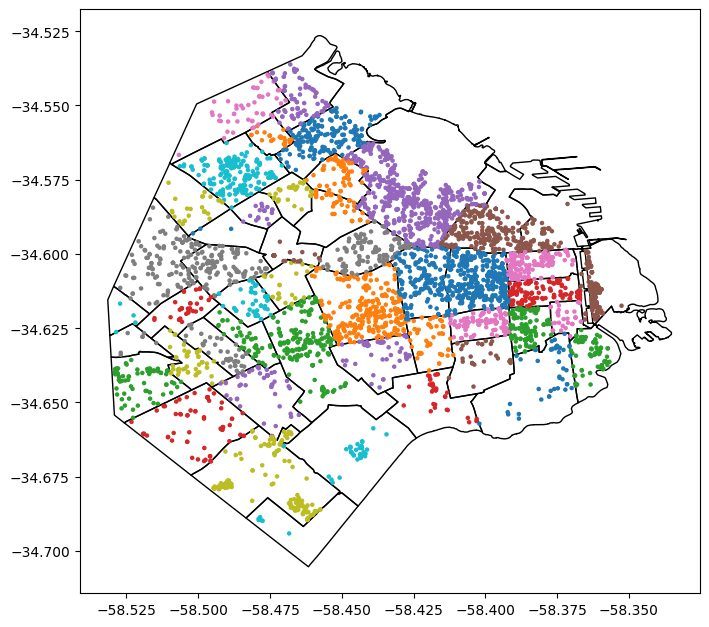

In [116]:
df = pd.read_csv("../storage/data/arg_venta_data.csv")

# Limites administrativos (barrios / comunas)
barrios = gpd.read_file("../barrios.geojson")

# Construir GeoDataFrame en lon/lat
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitud, df.latitud),
    crs="EPSG:4326"
)

# Unificar CRS para el join espacial
barrios = barrios.to_crs(gdf.crs)

# Asignar barrio/comuna (puntos fuera del poligono quedan con NaN)
gdf = gpd.sjoin(
    gdf,
    barrios[["nombre", "comuna", "geometry"]],
    how="left",
    predicate="within"
).rename(columns={"nombre": "barrio"})

# Mapa rapido: distribucion de puntos por barrio
fig, ax = plt.subplots(figsize=(8, 8))
barrios.plot(ax=ax, edgecolor="black", facecolor="none")

gdf.plot(
    ax=ax,
    column="barrio",
    markersize=5,
    legend=False
)

ax.set_axis_off()
plt.show()


In [117]:
# ?????????????????????????????
# 1. Filtros de validez / vigencia
# ?????????????????????????????
# Solo registros vigentes (sin fecha de baja)
gdf = gdf[gdf["valido_hasta"].isna()]

# Campos minimos para EDA/modelado
gdf = gdf[gdf["precio"].notna()]
gdf = gdf[gdf["area_m2_total"].notna()]
gdf = gdf[gdf["ambientes"].notna()]

# ?????????????????????????????
# 2. Filtrar barrios con suficiente n (evita medias/modas inestables)
# ?????????????????????????????
min_obs_barrio = 5
gdf = gdf[gdf.groupby("barrio")["barrio"].transform("size") >= min_obs_barrio]

# ?????????????????????????????
# 3. Imputaciones simples (supuestos explicitables)
# ?????????????????????????????
# Ojo: 0 no significa "missing". Es un supuesto pragmatico para no perder filas.
gdf["expensas"] = gdf["expensas"].fillna(0)
gdf["banos"] = gdf["banos"].fillna(1)
gdf["cocheras"] = gdf["cocheras"].fillna(0)
gdf["area_m2_descubierta"] = gdf["area_m2_descubierta"].fillna(0)

# ?????????????????????????????
# 4. Antiguedad
# ?????????????????????????????
# En algunas publicaciones "antiguedad" viene como anio de construccion (ej: 2012).
# Regla: si cae en rango [1800, anio_actual] lo interpretamos como anio y lo pasamos a antiguedad.
# Si es negativa o extremadamente alta, lo tratamos como missing.

current_year = datetime.now().year

def normalize_antiguedad(x):
    if pd.isna(x):
        return np.nan
    try:
        x = float(x)
    except Exception:
        return np.nan

    if 1800 <= x <= current_year:
        return current_year - x
    if x < 0 or x > 300:
        return np.nan
    return x

gdf["antiguedad"] = gdf["antiguedad"].apply(normalize_antiguedad)

# Imputar por barrio
gdf["antiguedad"] = gdf["antiguedad"].fillna(
    gdf.groupby("barrio")["antiguedad"].transform("mean")
)
# Fallback global
gdf["antiguedad"] = gdf["antiguedad"].fillna(gdf["antiguedad"].median())

# ?????????????????????????????
# 5. Estado: moda por (barrio, antiguedad)
# ?????????????????????????????
gdf["antiguedad_cat"] = gdf["antiguedad"].round().astype("Int64")

estado_moda = (
    gdf
    .dropna(subset=["estado"])
    .groupby(["barrio", "antiguedad_cat"])["estado"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
)

mask = gdf["estado"].isna()
gdf.loc[mask, "estado"] = (
    gdf.loc[mask]
    .set_index(["barrio", "antiguedad_cat"])
    .index
    .map(estado_moda)
)

# Fallback global
gdf["estado"] = gdf["estado"].fillna(gdf["estado"].mode().iloc[0])

orden_estado = {
    "Excelente": 5,
    "Muy Bueno": 4,
    "Bueno": 3,
    "Regular": 2,
    "A Refaccionar": 1
}

gdf["estado_num"] = gdf["estado"].map(orden_estado)


In [118]:
df_dolar = pd.read_csv("../storage/data/dolar_hoy.csv")

# Compatibilidad: el CSV puede tener columnas [tipo, operacion, valor] o [tipo_dolar, valor]
col_tipo = "tipo" if "tipo" in df_dolar.columns else "tipo_dolar"

if "operacion" in df_dolar.columns:
    dolar_oficial_venta = (
        df_dolar.loc[(df_dolar[col_tipo] == "oficial") & (df_dolar["operacion"] == "venta"), "valor"]
        .astype(float)
        .iloc[0]
    )
else:
    # Fallback: tomar el primer valor de oficial
    dolar_oficial_venta = (
        df_dolar.loc[df_dolar[col_tipo] == "oficial", "valor"]
        .astype(float)
        .iloc[0]
    )

# Convertir precios en ARS a USD
mask_ars = gdf["moneda"].eq("ARS")
gdf.loc[mask_ars, "precio"] = gdf.loc[mask_ars, "precio"] / dolar_oficial_venta

# Agregar log-precio (ayuda a estabilizar varianza)
gdf["log_precio"] = np.log(gdf["precio"])
gdf = gdf[np.isfinite(gdf["log_precio"])].copy()


In [119]:
gdf = gdf.reset_index(drop=True)


## Hipotesis

El precio de una propiedad depende de su superficie (en m2) y de la cantidad de ambientes. Sin embargo, la hipotesis es que **la relacion entre estas variables y el precio no es espacialmente homogenea**: los efectos marginales pueden variar segun el barrio/ubicacion.

Ejemplo: a igual superficie y ambientes, el premio por "estar en cierto barrio" y/o el impacto de sumar un ambiente podria ser distinto en Palermo que en Caballito.

### Decisiones de limpieza (para interpretar los graficos)

- Se filtran avisos no vigentes (`valido_hasta` nulo) y registros sin variables basicas (precio, area, ambientes).
- Se convierten precios en ARS a USD usando el dolar oficial (venta) del dia de scraping.
- Se aplican imputaciones simples para no perder demasiadas filas (expensas/banos/cocheras/area descubierta).

---

## Analisis

Para explorar esta hipotesis, se analiza la relacion entre el precio (USD) y la superficie (m2), estratificando por cantidad de ambientes y comparando patrones por barrio.


In [120]:
densidad_naive = (
    gdf
    .groupby('barrio')
    .size()
    .sort_values(ascending=False)
)

densidad_naive


barrio
Palermo              653
Balvanera            329
Caballito            261
Recoleta             208
Villa Urquiza        194
Puerto Madero        189
Belgrano             174
Almagro              161
Flores               151
San Nicolas          150
Constitucion         148
Monserrat            148
Villa Lugano         132
San Cristobal        122
Villa Crespo         119
Villa Del Parque     104
Villa Devoto         101
Nuñez                 89
La Boca               87
Liniers               82
Retiro                72
Colegiales            66
Mataderos             55
Villa Santa Rita      52
Boedo                 48
Parque Chacabuco      45
Barracas              44
Parque Avellaneda     42
Velez Sarsfield       42
Villa Luro            41
Saavedra              41
Paternal              39
Floresta              39
Chacarita             38
Nueva Pompeya         31
Villa Ortuzar         30
San Telmo             30
Monte Castro          28
Villa Soldati         27
Villa Pueyrredon  

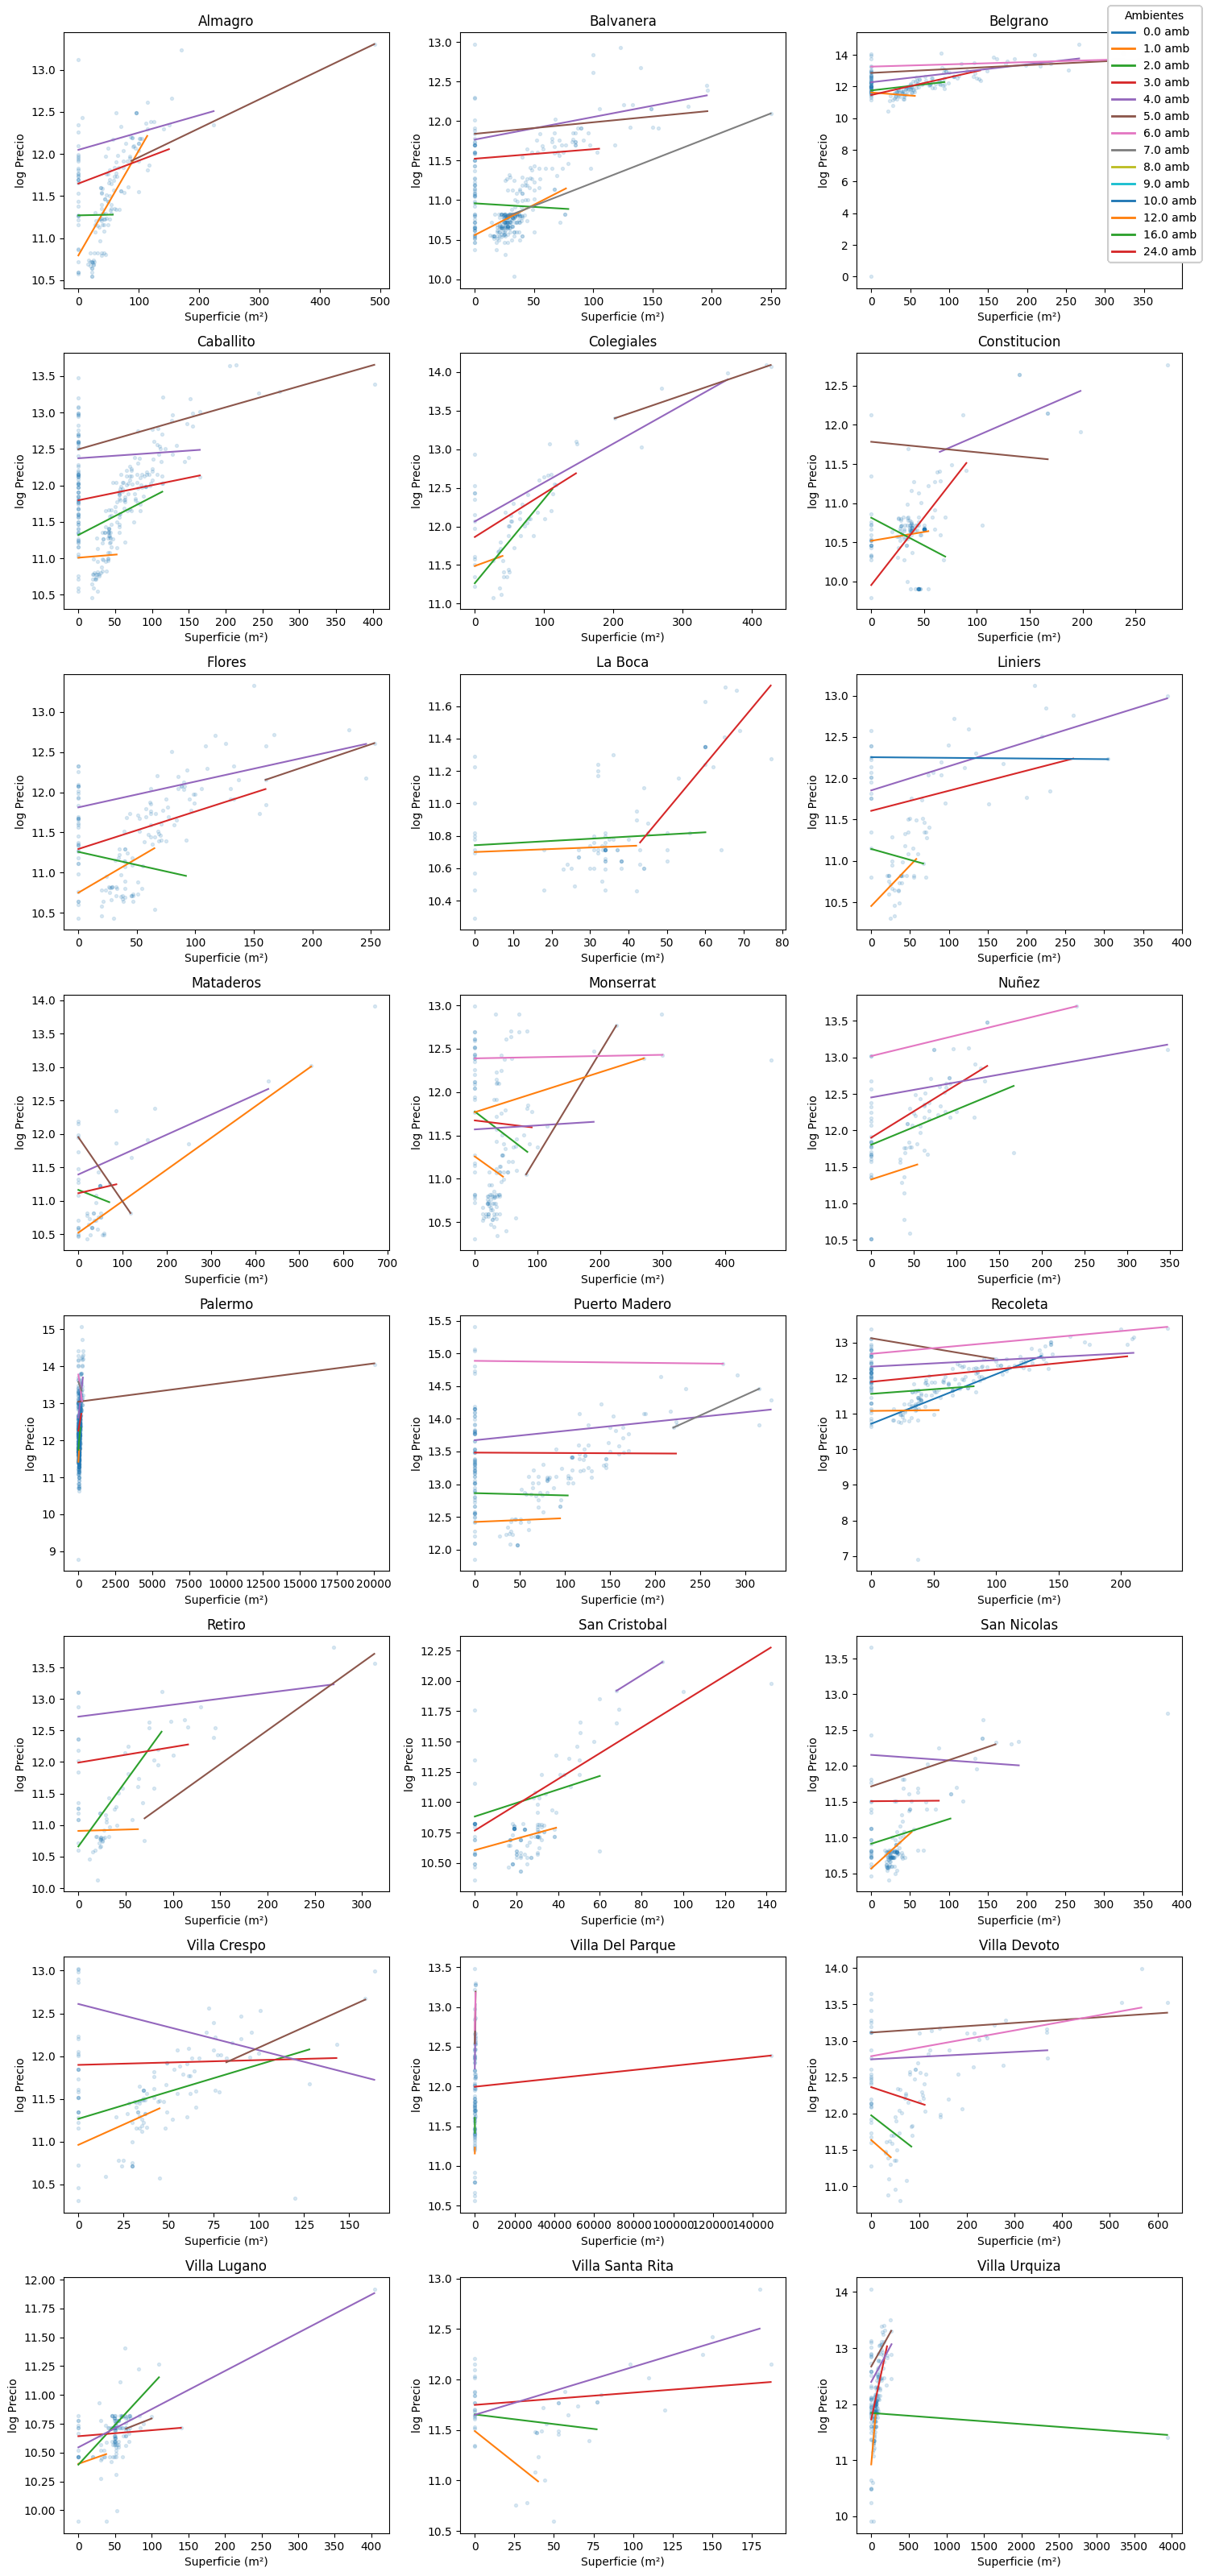

In [121]:
min_obs = 50

barrios_con_observaciones = (
    gdf
    .groupby('barrio')
    .size()
    .loc[lambda s: s >= min_obs]
    .index
    .tolist()
)

n = len(barrios_con_observaciones)
ncols = 3
nrows = int(np.ceil(n / ncols))

import matplotlib.cm as cm
from matplotlib.lines import Line2D

ambientes = sorted(gdf['ambientes'].unique())
cmap = cm.get_cmap("tab10")

color_por_amb = {
    amb: cmap(i % cmap.N)
    for i, amb in enumerate(ambientes)
}

# Límites globales
xmin = gdf['area_m2_total'].min()
xmax = 400

ymin = gdf['log_precio'].min()
ymax = 2*1e6


fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for ax, barrio in zip(axes, barrios_con_observaciones):

    gdf_b = gdf[gdf['barrio'] == barrio]

    # ---- densidad de puntos ----
    ax.scatter(
        gdf_b['area_m2_total'],
        gdf_b['log_precio'],
        s=8,
        alpha=0.15
    )

    for amb in sorted(gdf_b['ambientes'].unique()):
        sub = gdf_b[gdf_b['ambientes'] == amb]

        X = sm.add_constant(sub['area_m2_total'])
        y = sub['log_precio']

        model = sm.OLS(y, X).fit()

        x_grid = np.linspace(
            sub['area_m2_total'].min(),
            sub['area_m2_total'].max(),
            100
        )

        y_hat = model.predict(
            sm.add_constant(x_grid)
        )

        ax.plot(
            x_grid,
            y_hat,
            color=color_por_amb[amb],
            label=f'{amb} amb'
        )



    ax.set_title(barrio)
    ax.set_xlabel('Superficie (m²)')
    ax.set_ylabel('log Precio')

    legend_elements = [
        Line2D(
            [0], [0],
            color=color_por_amb[amb],
            lw=2,
            label=f'{amb} amb'
        )
        for amb in ambientes
    ]

    fig.legend(
        handles=legend_elements,
        loc='upper right',
        title='Ambientes'
    )

for ax in axes[len(barrios_con_observaciones):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


## Analisis exploratorio espacial del precio por m2

Se calcula el **precio por metro cuadrado** como `precio / area_m2_total` y se aplica kriging para obtener una superficie espacial suave que ayude a visualizar, de forma exploratoria, la estructura espacial del precio en la ciudad.

Notas:

- Para el variograma/kriging se reproyectan las coordenadas a un CRS metrico (EPSG:3857) para trabajar en metros.
- El kriging aca es **exploratorio** (no es una validacion formal del modelo).

El mapa suele mostrar valores altos en la franja costera (por ejemplo, Puerto Madero) y un gradiente con precios menores hacia el sudoeste.


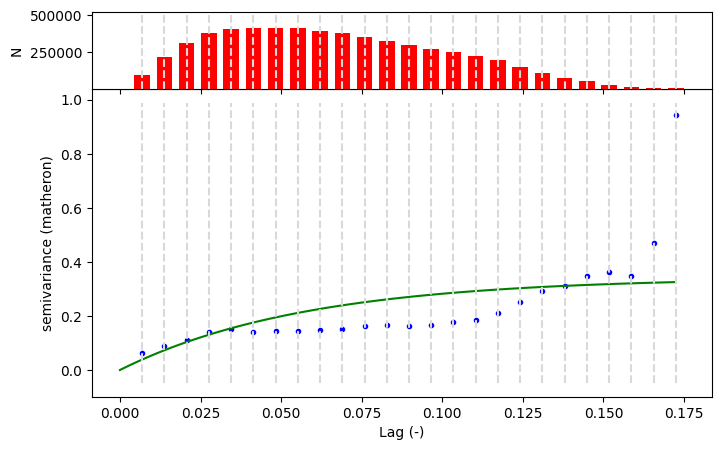

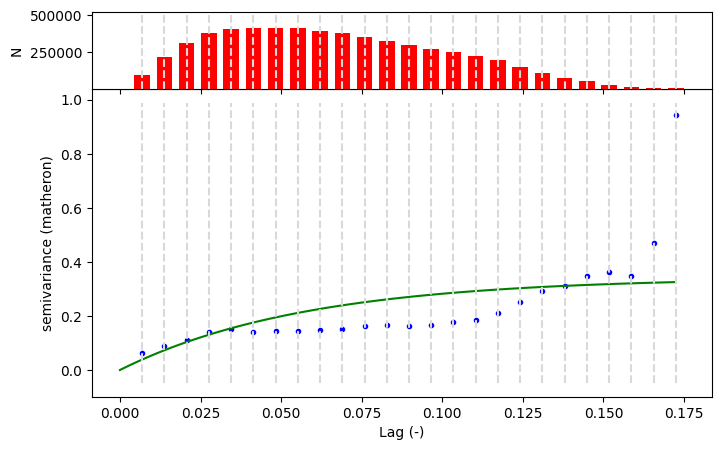

In [124]:
# Reproyeccion a CRS metrico para usar distancias (metros)
gdf_m = gdf.to_crs(epsg=3857)
barrios_m = gpd.read_file("../barrios.geojson").to_crs(gdf_m.crs)
caba_polygon = unary_union(barrios_m.geometry)

# Grilla para prediccion (mas chica para que el notebook sea liviano)
xmin, ymin, xmax, ymax = caba_polygon.bounds
grid_size = 300

xs = np.linspace(xmin, xmax, grid_size)
ys = np.linspace(ymin, ymax, grid_size)

xx, yy = np.meshgrid(xs, ys)
coords_grid = np.column_stack([xx.ravel(), yy.ravel()])

gdf_grid = gpd.GeoDataFrame(
    geometry=[Point(xy) for xy in coords_grid],
    crs=gdf_m.crs
)

gdf_grid = gdf_grid[gdf_grid.within(caba_polygon)]
coords_grid = np.array([(p.x, p.y) for p in gdf_grid.geometry])

# Target: precio por m2
precio_por_m2 = gdf_m["precio"] / gdf_m["area_m2_total"]

mask = (
    np.isfinite(precio_por_m2) &
    (gdf_m["area_m2_total"] >= 15)
)

# Coordenadas y variable (en metros)
x = gdf_m.geometry.x.values[mask]
y = gdf_m.geometry.y.values[mask]
v = precio_por_m2.values[mask]

coords = np.column_stack([x, y])

# Si hay coords duplicadas exactas, el variograma/kriging pueden fallar.
# Jitter minimo en metros solo para esas filas (reproducible).
np.random.seed(42)
_, uniq_counts = np.unique(coords, axis=0, return_counts=True)
if (uniq_counts > 1).any():
    # identificamos duplicados de forma simple por hashing
    import pandas as _pd
    _dfc = _pd.DataFrame(coords, columns=["x", "y"])
    dup_mask = _dfc.duplicated(subset=["x", "y"], keep=False).to_numpy()
    coords[dup_mask, 0] += np.random.normal(0, 1.0, size=dup_mask.sum())
    coords[dup_mask, 1] += np.random.normal(0, 1.0, size=dup_mask.sum())
    x = coords[:, 0]
    y = coords[:, 1]

V = Variogram(
    coords,
    v,
    model="exponential",
    n_lags=25
)

range_ = V.parameters[0]
sill = V.parameters[1]
nugget = V.parameters[2]

V.plot()


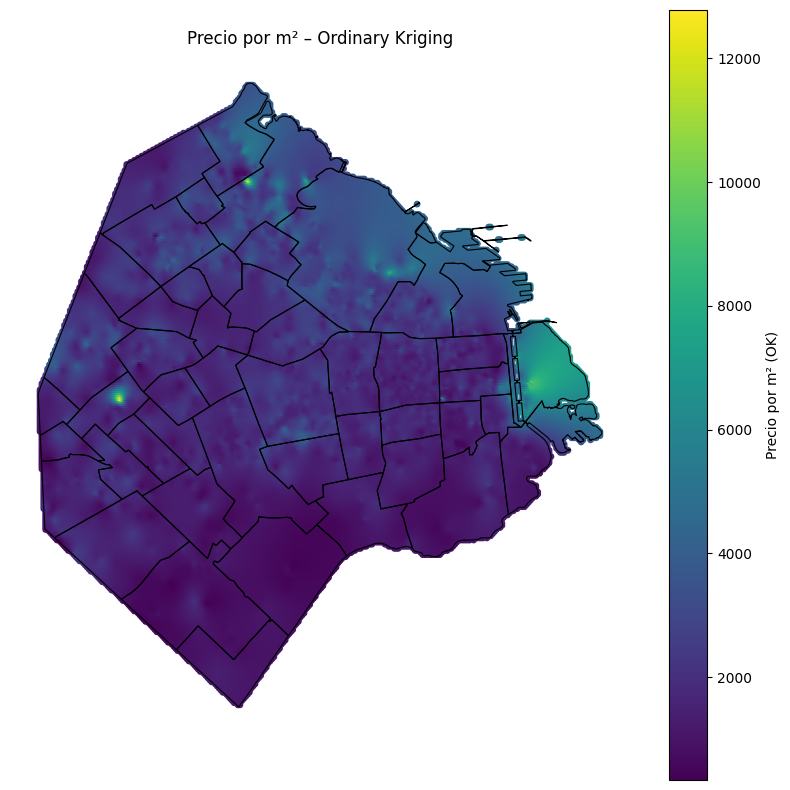

In [112]:
# Kriging en CRS metrico (x/y en metros)



UK = UniversalKriging(
    x,
    y,
    v,
    variogram_model="spherical",
    variogram_parameters={
        "range": range_,
        "sill": sill,
        "nugget": nugget
    },
    drift_terms=["regional_linear"]
)


z, ss = UK.execute(
    'points',
    coords_grid[:, 0],
    coords_grid[:, 1]
)
z = np.ma.filled(z, np.nan)

gdf_grid['precio_m2_ok'] = z

fig, ax = plt.subplots(figsize=(10, 10))

sc = ax.scatter(
    gdf_grid.geometry.x,
    gdf_grid.geometry.y,
    c=gdf_grid['precio_m2_ok'],
    s=15,
)

barrios_m.boundary.plot(ax=ax, color='black', linewidth=0.8)

plt.colorbar(sc, ax=ax, label='Precio por m² (OK)')
ax.set_title('Precio por m² – Ordinary Kriging')
ax.set_axis_off()
plt.show()


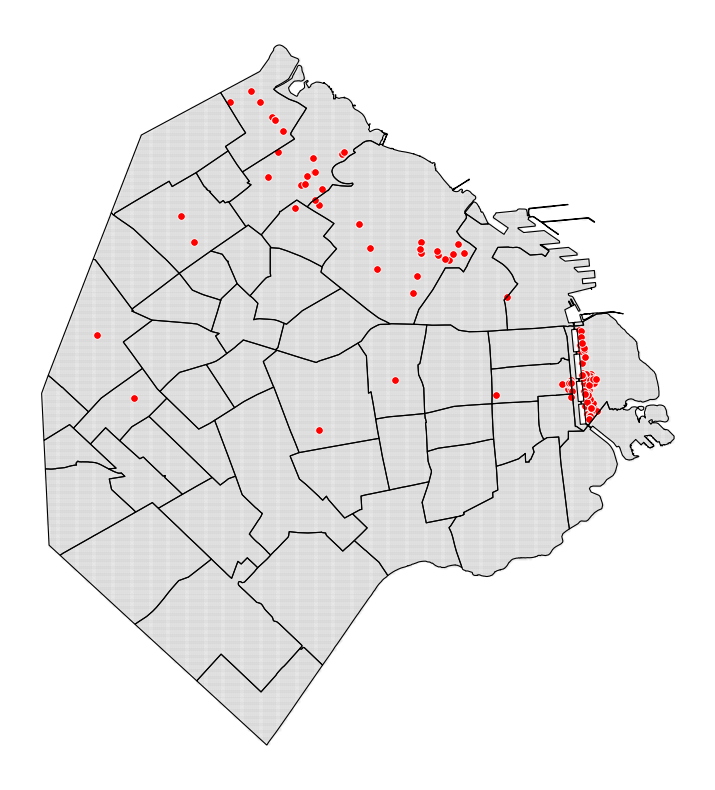

In [113]:
gdf = gdf.copy()

# Precio por m2
gdf["precio_sobre_m2"] = gdf["precio"] / gdf["area_m2_total"]
gdf.loc[~np.isfinite(gdf["precio_sobre_m2"]), "precio_sobre_m2"] = np.nan

s = gdf["precio_sobre_m2"].dropna()

q1, q3 = s.quantile([0.25, 0.75])
iqr = q3 - q1
lo = q1 - 1.5 * iqr
hi = q3 + 1.5 * iqr

outliers_iqr = gdf[(gdf["precio_sobre_m2"] < lo) | (gdf["precio_sobre_m2"] > hi)]

lo_ext = q1 - 3 * iqr
hi_ext = q3 + 3 * iqr
outliers_super = gdf[(gdf["precio_sobre_m2"] < lo_ext) | (gdf["precio_sobre_m2"] > hi_ext)]

# Plot espacial: usar la geometria reproyectada para que coincida con el mapa
# (tomamos las mismas filas por indice)
gdf_m = gdf.to_crs(epsg=3857)
barrios_m = gpd.read_file("../barrios.geojson").to_crs(gdf_m.crs)

outliers_iqr_m = gdf_m.loc[outliers_iqr.index]  # conserva geometry en EPSG:3857

fig, ax = plt.subplots(figsize=(10, 10))

# Base: grilla (si existe de la seccion de kriging)
try:
    gdf_grid.plot(ax=ax, color="lightgray", alpha=0.25, markersize=5)
except Exception:
    pass

# Outliers
outliers_iqr_m.plot(ax=ax, color="red", markersize=30, edgecolor="white", linewidth=0.6)

barrios_m.boundary.plot(ax=ax, color="black", linewidth=0.8)

ax.set_title("Outliers (IQR) en precio por m2")
ax.set_axis_off()
plt.show()


In [114]:
export_path = "../storage/data/arg_venta_caba_processed.csv"

# Exportar como tabla (sin columna geometry)
cols = [c for c in gdf.columns if c != "geometry"]
gdf[cols].to_csv(export_path, index=False)

print(f"Exportado: {export_path} (filas={len(gdf)})")
